# horizon leadtime vs graph structure

In [1]:
from src.dataloading.epiconfig.epiconfig import EpiConfig
from src.dataloading.epidataorchestration.orchestrator import EpiDataOrchestrator
from src.dataloading.dataloaders import BaseLineDataLoaderManager, DeepDataLoaderManager, GraphDataLoaderManager
from src.models import LSTMModel, GCN2Model, PersistenceModel, ClimaScaleModel, ClimateologyModel
from tqdm import tqdm

In [ ]:
horizon_leadtime_options = range(10)
epiconfigs               = []
dataorchs                = []

for hl in tqdm(horizon_leadtime_options):

    cfg = EpiConfig(
            disease         = 'influenza',
            country         = 'germany',
            level           = 'nuts3',

            min_date        = '2012-06-01',
            max_date        = '2020-06-01',

            horizon_leadtime    = hl,

            feature_popsize         = True,
            feature_popdens         = True,
            feature_gisd            = False,
            feature_popage          = False,
            feature_kreise_classes  = False,
            feature_borders         = False,

            sequence_length     = 4,
            normalization_method='zscore',
            
            log_transform       = ['incidence']     
            )    

    epiconfigs.append(cfg)
    dataorchs.append(EpiDataOrchestrator(cfg).build())


n_epochs        = 250
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.2, 'patience': 5},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

ALLMODELS = []

for idx, hl in enumerate(horizon_leadtime_options):

    model_naming_addition = f"_hl{hl}"

    dataloader_baselines    = BaseLineDataLoaderManager(dataorchs[idx])
    dataloader_deepmodel    = DeepDataLoaderManager(dataorchs[idx]).build()

    graphloader_identity    = GraphDataLoaderManager(dataorchs[idx]).retrieve_static_graph('graph1').build()
    graphloader_geographic  = GraphDataLoaderManager(dataorchs[idx]).retrieve_static_graph('graph2').build()      
    graphloader_random      = GraphDataLoaderManager(dataorchs[idx]).retrieve_static_graph('graph3').build()    
    graphloader_commuting   = GraphDataLoaderManager(dataorchs[idx]).retrieve_static_graph('graph16').build()      

    # BASELINES
    persistence = PersistenceModel(dataloader_baselines, f'persistence'+model_naming_addition)
    persistence.train()
    persistence.forecast('test')

    climateology = ClimateologyModel(dataloader_baselines, f'climateology'+model_naming_addition)
    climateology.train()
    climateology.forecast('test')

    climascale = ClimaScaleModel(dataloader_baselines, f'climascale'+model_naming_addition)
    climascale.train()
    climascale.forecast('test')

    # LSTM
    lstm = LSTMModel(dataloader_deepmodel, name = 'lstm'+model_naming_addition, verbose = 2)
    lstm.set_model_hparams()
    lstm.set_global_hparams(**global_hparams)
    lstm.train()
    lstm.forecast('test')

    gcn_identity = GCN2Model(graphloader_identity, name = 'gcn_id'+model_naming_addition, verbose = 2)
    gcn_identity.set_model_hparams(dropout = 0.3, self_loops=False)
    gcn_identity.set_global_hparams(**global_hparams)
    gcn_identity.train()
    gcn_identity.forecast('test')

    gcn_geographic = GCN2Model(graphloader_geographic, name = 'gcn_geo'+model_naming_addition, verbose = 2)
    gcn_geographic.set_model_hparams(dropout = 0.3, self_loops=False)
    gcn_geographic.set_global_hparams(**global_hparams)
    gcn_geographic.train()
    gcn_geographic.forecast('test')


    gcn_random = GCN2Model(graphloader_random, name = 'gcn_rnd'+model_naming_addition, verbose = 2)
    gcn_random.set_model_hparams(dropout = 0.3, self_loops=False)
    gcn_random.set_global_hparams(**global_hparams)
    gcn_random.train()
    gcn_random.forecast('test')

    gcn_commuting = GCN2Model(graphloader_commuting, name = 'gcn_comm'+model_naming_addition, verbose = 2)
    gcn_commuting.set_model_hparams(dropout = 0.3, self_loops=False)
    gcn_commuting.set_global_hparams(**global_hparams)
    gcn_commuting.train()
    gcn_commuting.forecast('test')

    hl_models = [persistence,climateology,climascale, lstm, gcn_identity, gcn_geographic, gcn_random, gcn_commuting]

    ALLMODELS.append(hl_models)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:05<00:00,  2.63s/it]


In [17]:
lstm.save('somelstm')

AttributeError: 'LSTMModel' object has no attribute 'deepfamily'

In [6]:
from src.evaluation import Evaluator

evaluators = []

for hl, hl_models in zip(horizon_leadtime_options, ALLMODELS):
    evaluator = Evaluator(hl_models)
    evaluator.add_evaluation(horizon=0, dataset='test')
    evaluators.append(evaluator)

computing metrics nodewise: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3200/3200 [00:08<00:00, 377.67it/s]


In [7]:
import pandas as pd

def describe_evaluation(metrics: pd.DataFrame, persistence_name: str) -> None:
    """
    Print a structured summary of evaluation results for diagnostic purposes.
    """
    models = metrics['model'].unique().tolist()
    
    print("=" * 60)
    print("MODELS")
    print("=" * 60)
    print(metrics['model'].unique().tolist())
    print(f"n nodes: {metrics['node'].nunique()}")
    print()

    print("=" * 60)
    print("GLOBAL CCC PER MODEL")
    print("=" * 60)
    summary = (
        metrics.groupby('model')['ccc']
        .agg(['mean','median','std', 
              lambda x: (x > 0).mean()])
        .round(4)
    )
    summary.columns = ['mean', 'median', 'std', 'frac_positive']
    print(summary.to_string())
    print()

    print("=" * 60)
    print("CCC RELATIVE TO PERSISTENCE (mean delta per model)")
    print("=" * 60)
    metrics['node']  = metrics['node'].astype(str)   # unify to str regardless of source
    metrics['model'] = metrics['model'].astype(str)


    persistence_ccc = metrics[metrics['model'] == persistence_name][['node','ccc']].rename(columns={'ccc':'ccc_persistence'})
    merged = metrics.merge(persistence_ccc, on='node', how='inner')
    merged['delta'] = merged['ccc'] - merged['ccc_persistence']

    models = merged['model'].unique()

    for model in models:
        if model == persistence_name:
            continue
        m = merged[merged['model'] == model]
        print(f"  {model:<30}  mean_delta={m['delta'].mean():+.4f}  "
            f"median_delta={m['delta'].median():+.4f}  "
            f"nodes_beating_persistence={(m['delta']>0).sum()}/{len(m)}")
    print()

    print("=" * 60)
    print("HARD NODES (bottom 80 persistence CCC)")
    print("=" * 60)
    hard_nodes = (
        metrics[metrics['model'] == persistence_name]
        .nsmallest(80, 'ccc')['node'].tolist()
    )
    hard = metrics[metrics['node'].isin(hard_nodes)]
    hard_summary = (
        hard.groupby('model')['ccc']
        .agg(['mean','median'])
        .round(4)
    )
    print(hard_summary.to_string())
    print()

    print("=" * 60)
    print("EASY NODES (top 80 persistence CCC)")
    print("=" * 60)
    easy_nodes = (
        metrics[metrics['model'] == persistence_name]
        .nlargest(80, 'ccc')['node'].tolist()
    )
    easy = metrics[metrics['node'].isin(easy_nodes)]
    easy_summary = (
        easy.groupby('model')['ccc']
        .agg(['mean','median'])
        .round(4)
    )
    print(easy_summary.to_string())
    print()

    print("=" * 60)
    print("OTHER METRICS — GLOBAL MEAN PER MODEL")
    print("=" * 60)
    other_metrics = ['mae', 'rmse', 'mbe', 'vr', 'pearson']
    available     = [m for m in other_metrics if m in metrics.columns]
    print(metrics.groupby('model')[available].mean().round(4).to_string())
    print()

    print("=" * 60)
    print("VARIANCE RATIO (vr) DISTRIBUTION — smoothing diagnostic")
    print("=" * 60)
    if 'vr' in metrics.columns:
        vr_summary = (
            metrics.groupby('model')['vr']
            .agg(['mean', 'median', lambda x: (x < 1).mean()])
            .round(4)
        )
        vr_summary.columns = ['mean', 'median', 'frac_underdispersed']
        print(vr_summary.to_string())
    else:
        print("  vr not in metrics")
    print()

    print("=" * 60)
    print("RAW METRIC TABLE (mean) — full overview")
    print("=" * 60)
    all_metric_cols = [c for c in metrics.columns if c not in ['node','model']]
    print(metrics.groupby('model')[all_metric_cols].mean().round(4).to_string())

In [8]:
# Assuming you have a list of evaluators, one per horizon
for hl, evaluator in zip(horizon_leadtime_options, evaluators):
    print(f"\n{'='*60}")
    print(f"HORIZON LEADTIME: {hl}")
    print(f"{'='*60}")
    metrics = evaluator.data_compilation.get_data(0, 'test')['metrics'].copy()
    metrics['node']  = metrics['node'].astype(str)
    metrics['model'] = metrics['model'].astype(str)
    describe_evaluation(metrics, persistence_name=f'persistence_hl{hl}')


HORIZON LEADTIME: 1
MODELS
['persistence_hl1', 'climateology_hl1', 'climascale_hl1', 'lstm_hl1', 'gcn_id_hl1', 'gcn_geo_hl1', 'gcn_rnd_hl1', 'gcn_comm_hl1']
n nodes: 400

GLOBAL CCC PER MODEL
                    mean  median     std  frac_positive
model                                                  
climascale_hl1    0.8697  0.9042  0.1202         0.9975
climateology_hl1  0.8428  0.8663  0.1074         0.9975
gcn_comm_hl1      0.8962  0.9213  0.0881         0.9975
gcn_geo_hl1       0.9008  0.9240  0.0820         0.9975
gcn_id_hl1        0.8869  0.9116  0.0902         0.9975
gcn_rnd_hl1       0.8899  0.9128  0.0892         0.9975
lstm_hl1          0.8953  0.9211  0.0906         0.9975
persistence_hl1   0.8657  0.8969  0.1078         0.9975

CCC RELATIVE TO PERSISTENCE (mean delta per model)
  climateology_hl1                mean_delta=-0.0229  median_delta=-0.0096  nodes_beating_persistence=185/400
  climascale_hl1                  mean_delta=+0.0040  median_delta=+0.0150  nodes_bea

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

for hl in horizon_leadtime_options:

    eval = evaluators[hl - 1]
    persistence_name = f'persistence_hl{hl}'

    # ── 1. pull metrics & check exact model names ──────────────────────────
    metrics = eval.data_compilation.get_data(0, 'test')['metrics'].copy()
    metrics['node']  = metrics['node'].astype(str)   # unify to str regardless of source
    metrics['model'] = metrics['model'].astype(str)

    print(metrics['model'].unique())   # <-- confirm exact persistence name here


    persistence_ccc = metrics[metrics['model'] == persistence_name][['node','ccc']].rename(columns={'ccc':'ccc_persistence'})
    merged = metrics.merge(persistence_ccc, on='node', how='inner')
    merged['delta'] = merged['ccc'] - merged['ccc_persistence']

    models = merged['model'].unique()

    for model in models:
            if model == persistence_name:
                continue
            m = merged[merged['model'] == model]
            print(f"  {model:<30}  mean_delta={m['delta'].mean():+.4f}  "
                f"median_delta={m['delta'].median():+.4f}  "
                f"nodes_beating_persistence={(m['delta']>0).sum()}/{len(m)}")


['persistence_hl1' 'climateology_hl1' 'climascale_hl1' 'lstm_hl1'
 'gcn_id_hl1' 'gcn_geo_hl1' 'gcn_rnd_hl1' 'gcn_comm_hl1']
  climateology_hl1                mean_delta=-0.0229  median_delta=-0.0096  nodes_beating_persistence=185/400
  climascale_hl1                  mean_delta=+0.0040  median_delta=+0.0150  nodes_beating_persistence=276/400
  lstm_hl1                        mean_delta=+0.0299  median_delta=+0.0248  nodes_beating_persistence=384/400
  gcn_id_hl1                      mean_delta=+0.0216  median_delta=+0.0164  nodes_beating_persistence=338/400
  gcn_geo_hl1                     mean_delta=+0.0354  median_delta=+0.0293  nodes_beating_persistence=362/400
  gcn_rnd_hl1                     mean_delta=+0.0245  median_delta=+0.0212  nodes_beating_persistence=337/400
  gcn_comm_hl1                    mean_delta=+0.0308  median_delta=+0.0272  nodes_beating_persistence=363/400


IndexError: list index out of range

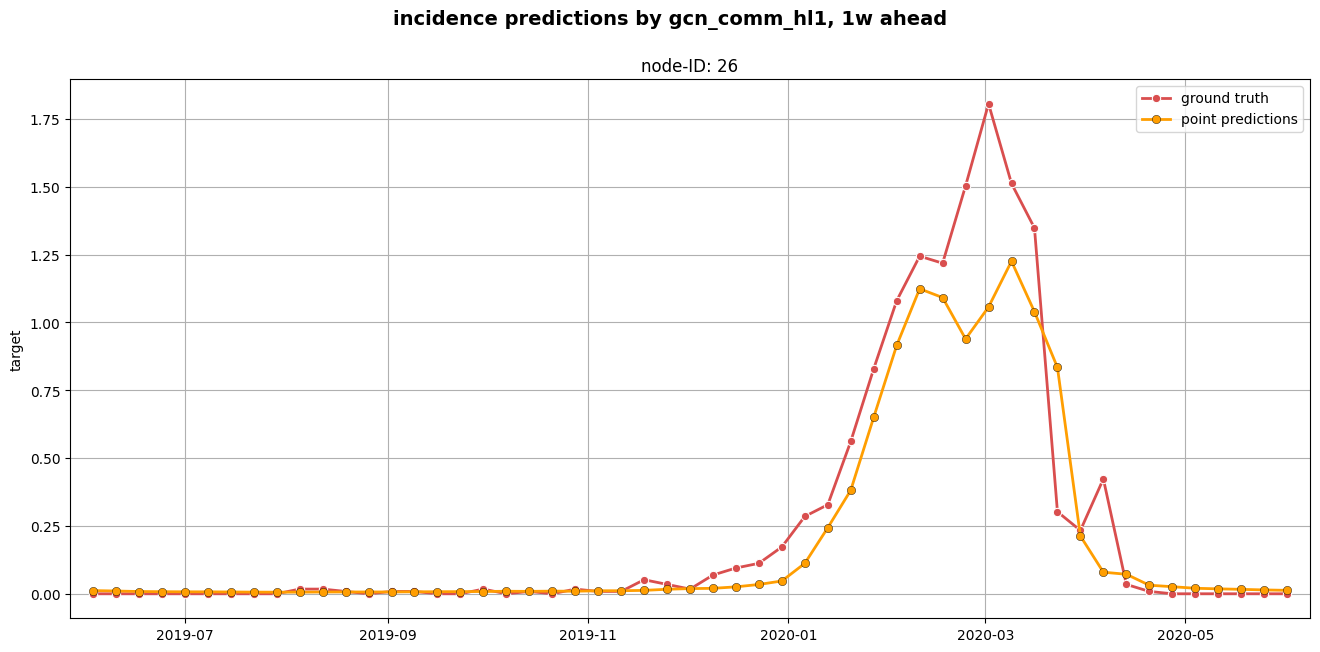

In [10]:
ALLMODELS[0][7].show_forecasts(26).show()

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np

def plot_model_across_horizons(
    ALLMODELS,
    evaluators,
    model_indices: list,
    horizon_leadtimes: list,
    metrics: list = ['ccc', 'smape'],
    figsize: tuple = (16, 5)
):
    """
    Boxplot of specified metrics per horizon leadtime for selected models.

    Parameters
    ----------
    ALLMODELS        : list of lists — ALLMODELS[hl_idx][model_idx]
    evaluators       : list of Evaluator objects, one per horizon leadtime
    model_indices    : which model indices to include, e.g. [3, 4, 5, 6, 7]
    horizon_leadtimes: list of horizon leadtime values, e.g. [1,2,3,4,5,6]
    metrics          : which metrics to plot
    figsize          : figure size
    """
    # ── collect per-node metrics across horizons ──────────────────────────
    records = []

    for hl_idx, hl in enumerate(horizon_leadtimes):
        metrics_df = (
            evaluators[hl_idx]
            .data_compilation
            .get_data(0, 'test')['metrics']
            .copy()
        )
        metrics_df['model'] = metrics_df['model'].astype(str)
        metrics_df['node']  = metrics_df['node'].astype(str)

        # keep only requested model indices
        model_names = [
            ALLMODELS[hl_idx][i].name for i in model_indices
        ]
        metrics_df = metrics_df[metrics_df['model'].isin(model_names)]

        # strip the _hlN suffix for a clean label
        metrics_df['model_label'] = metrics_df['model'].str.replace(
            r'_hl\d+$', '', regex=True
        )
        metrics_df['horizon'] = f'hl{hl}'
        metrics_df['hl_num']  = hl
        records.append(metrics_df)

    df = pd.concat(records, ignore_index=True)

    # consistent colour per model label
    labels   = sorted(df['model_label'].unique())
    palette  = dict(zip(labels, sns.color_palette('tab10', len(labels))))

    # ── plot ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(metrics), figsize=figsize, squeeze=False)

    for ax_idx, metric in enumerate(metrics):
        ax = axes[0][ax_idx]

        if metric not in df.columns:
            ax.set_title(f'{metric} — not found')
            continue

        sns.boxplot(
            data      = df,
            x         = 'horizon',
            y         = metric,
            hue       = 'model_label',
            palette   = palette,
            order     = [f'hl{h}' for h in horizon_leadtimes],
            linewidth = 0.6,
            fliersize = 1.5,
            ax        = ax,
        )

        ax.set_title(metric.upper(), fontsize=11, fontweight='bold')
        ax.set_xlabel('Horizon leadtime')
        ax.set_ylabel(metric)
        ax.legend(title='', fontsize=8, loc='best')
        sns.despine(ax=ax)

    fig.suptitle('Model comparison across forecast horizons', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    return fig

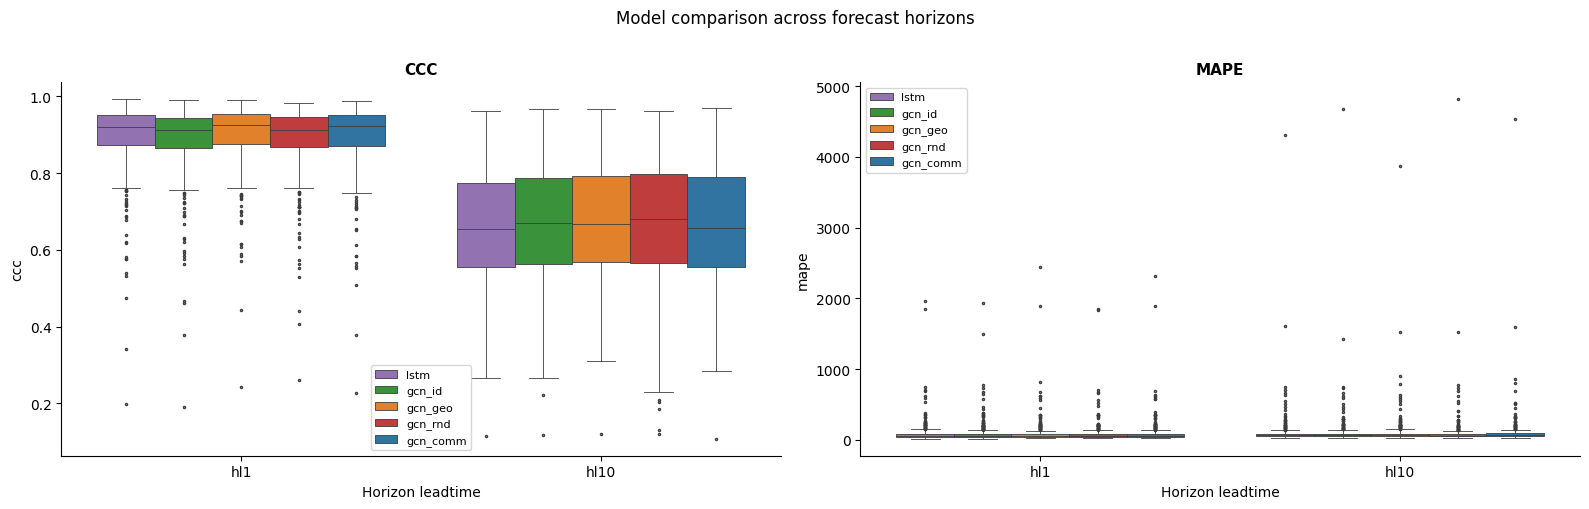

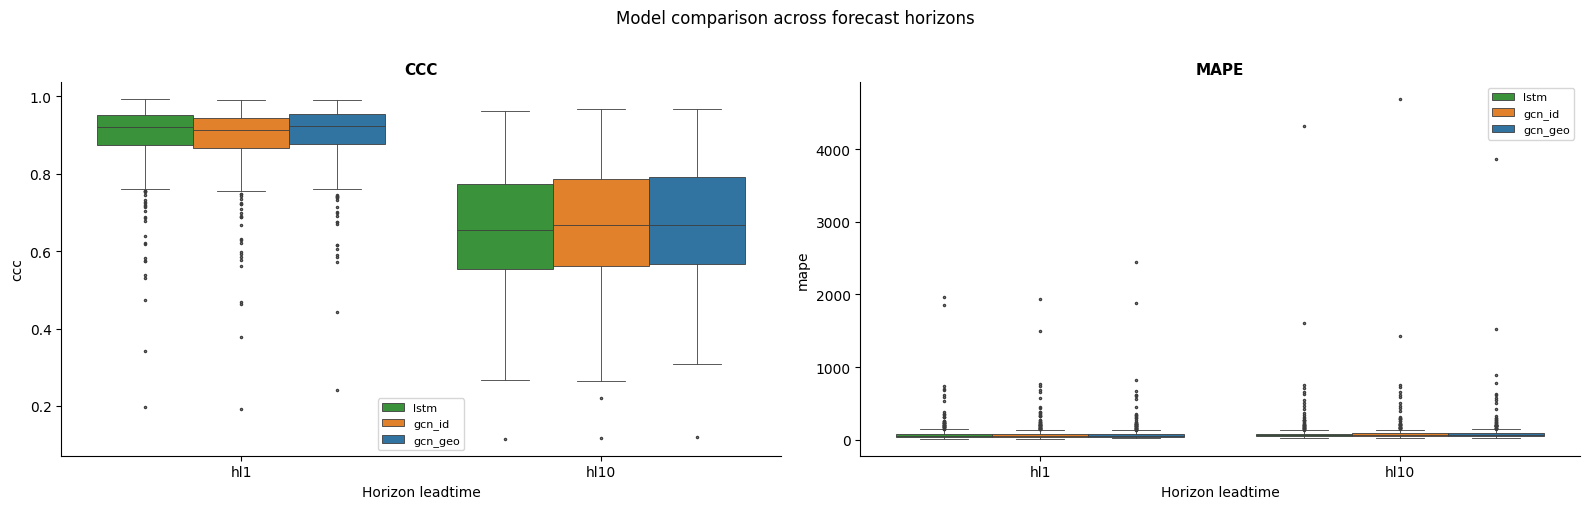

In [11]:
# All GCN variants + LSTM (indices 3–7)
fig = plot_model_across_horizons(
    ALLMODELS         = ALLMODELS,
    evaluators        = evaluators,
    model_indices     = [3, 4, 5, 6, 7],   # lstm, id, geo, rnd, comm
    horizon_leadtimes = horizon_leadtime_options,
    metrics           = ['ccc', 'mape'],
)

# Just geo vs identity vs LSTM to isolate the horizon degradation story
fig = plot_model_across_horizons(
    ALLMODELS         = ALLMODELS,
    evaluators        = evaluators,
    model_indices     = [3, 4, 5],          # lstm, identity, geo
    horizon_leadtimes = horizon_leadtime_options,
    metrics           = ['ccc', 'mape'],
)

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import torch
from scipy import stats

def analyse_peripherality(
    evaluators,
    ALLMODELS,
    horizon_idx:    int,
    horizon_label:  str,
    geo_graph_dlm,
    dataorchestrator,
    persistence_model_idx: int = 0,
):
    # ── 1. get per-node CCC for geo, identity, persistence ────────────────
    metrics = (
        evaluators[horizon_idx]
        .data_compilation
        .get_data(0, 'test')['metrics']
        .copy()
    )
    metrics['model'] = metrics['model'].astype(str)
    metrics['node']  = metrics['node'].astype(int)

    geo_name         = ALLMODELS[horizon_idx][5].name
    id_name          = ALLMODELS[horizon_idx][4].name
    persistence_name = ALLMODELS[horizon_idx][persistence_model_idx].name

    ccc_geo = (
        metrics[metrics['model'] == geo_name][['node', 'ccc']]
        .rename(columns={'ccc': 'ccc_geo'}).set_index('node')
    )
    ccc_id = (
        metrics[metrics['model'] == id_name][['node', 'ccc']]
        .rename(columns={'ccc': 'ccc_id'}).set_index('node')
    )
    ccc_pers = (
        metrics[metrics['model'] == persistence_name][['node', 'ccc']]
        .rename(columns={'ccc': 'ccc_persistence'}).set_index('node')
    )

    node_df = ccc_geo.join(ccc_id).join(ccc_pers)
    node_df['ccc_delta'] = node_df['ccc_geo'] - node_df['ccc_id']
    node_df = node_df.reset_index()

    print(f"CCC delta (geo - identity) at {horizon_label}")
    print(f"  mean:   {node_df['ccc_delta'].mean():.4f}")
    print(f"  median: {node_df['ccc_delta'].median():.4f}")
    print(f"  min:    {node_df['ccc_delta'].min():.4f}  (node {node_df.loc[node_df['ccc_delta'].idxmin(), 'node']})")
    print(f"  max:    {node_df['ccc_delta'].max():.4f}  (node {node_df.loc[node_df['ccc_delta'].idxmax(), 'node']})")

    # ── 2. incidence variance from predictions ────────────────────────────
    predictions = (
        evaluators[horizon_idx]
        .data_compilation
        .get_data(0, 'test')['predictions']
        .copy()
    )
    predictions['node'] = predictions['node'].astype(int)

    node_variance = (
        predictions[predictions['model'] == geo_name]
        .groupby('node')['target']
        .var()
        .reset_index()
        .rename(columns={'target': 'incidence_var'})
    )
    node_df = node_df.merge(node_variance, on='node', how='left')

    # ── 3. degree from geographic graph ───────────────────────────────────
    edge_index = geo_graph_dlm.graph.edge_index
    num_nodes  = node_df['node'].max() + 1

    degree = torch.zeros(num_nodes, dtype=torch.long)
    degree.scatter_add_(
        0, edge_index[1],
        torch.ones(edge_index.shape[1], dtype=torch.long)
    )
    degree_df = pd.DataFrame({'node': np.arange(num_nodes), 'degree': degree.numpy()})
    node_df   = node_df.merge(degree_df, on='node', how='left')

    print(f"\nDegree distribution:")
    print(f"  mean: {node_df['degree'].mean():.1f}  median: {node_df['degree'].median():.0f}  "
          f"min: {node_df['degree'].min()}  max: {node_df['degree'].max()}")

    # ── 4. correlations ───────────────────────────────────────────────────
    print("\n── Correlations with CCC delta ──────────────────────────────")
    for var, label in [
        ('degree',          'Geographic degree       '),
        ('ccc_persistence', 'Persistence CCC         '),
        ('incidence_var',   'Incidence variance (geo)'),
    ]:
        clean = node_df[['ccc_delta', var]].dropna()
        if len(clean) < 10:
            print(f"  {label}: insufficient data")
            continue
        r,   p_r   = stats.pearsonr( clean[var].astype(float), clean['ccc_delta'].astype(float))
        rho, p_rho = stats.spearmanr(clean[var].astype(float), clean['ccc_delta'].astype(float))
        print(f"  {label}  Pearson r={r:+.4f} (p={p_r:.4f})  Spearman ρ={rho:+.4f} (p={p_rho:.4f})")

    # grab for plot titles
    clean_deg  = node_df[['ccc_delta', 'degree']].dropna()
    clean_pers = node_df[['ccc_delta', 'ccc_persistence']].dropna()
    r_deg,  _  = stats.pearsonr( clean_deg['degree'].astype(float),          clean_deg['ccc_delta'].astype(float))
    r_pers, _  = stats.pearsonr( clean_pers['ccc_persistence'].astype(float), clean_pers['ccc_delta'].astype(float))
    rho_deg,  _ = stats.spearmanr(clean_deg['degree'].astype(float),          clean_deg['ccc_delta'].astype(float))
    rho_pers, _ = stats.spearmanr(clean_pers['ccc_persistence'].astype(float),clean_pers['ccc_delta'].astype(float))

    # ── 5. plot: 3 panels ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    def _scatter(ax, x, y, xlabel, title, r, rho):
        clean = node_df[[x, y]].dropna()
        ax.scatter(clean[x], clean[y], alpha=0.4, s=12, color='steelblue')
        try:
            slope, intercept, *_ = stats.linregress(
                clean[x].astype(float), clean[y].astype(float))
            xs = np.linspace(clean[x].min(), clean[x].max(), 100)
            ax.plot(xs, slope * xs + intercept, color='firebrick', linewidth=1.5)
        except Exception:
            pass
        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('CCC delta (geo − identity)')
        ax.set_title(f'{title}\nr={r:.3f}  ρ={rho:.3f}')

    _scatter(axes[0], 'degree',          'ccc_delta',
             'Geographic degree',     f'Degree vs CCC delta\n{horizon_label}',
             r_deg,  rho_deg)

    _scatter(axes[1], 'ccc_persistence', 'ccc_delta',
             'Persistence CCC',       f'Persistence CCC vs delta\n{horizon_label}',
             r_pers, rho_pers)

    # ── 6. choropleth ─────────────────────────────────────────────────────
    shapedata = dataorchestrator.data_context.local_shapedata.copy()
    gdf       = shapedata.merge(node_df, on='node', how='left')

    ax2  = axes[2]
    vmax = node_df['ccc_delta'].abs().quantile(0.98)
    gdf.plot(
        column       = 'ccc_delta',
        cmap         = 'RdYlGn',
        vmin         = -vmax,
        vmax         = vmax,
        legend       = True,
        ax           = ax2,
        missing_kwds = dict(color='lightgrey', label='No data'),
        legend_kwds  = dict(label='CCC geo − identity', shrink=0.7)
    )
    ax2.set_title(f'CCC delta (geo − identity)\n{horizon_label}')
    ax2.axis('off')

    plt.suptitle(
        f'What drives the geo vs identity benefit? ({horizon_label})',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

    return node_df, fig

In [13]:
def add_sociodemographic_correlations(node_df, dataorchestrator, evaluators, horizon_idx):
    """
    Add population size and density correlations to node_df,
    then print and plot.
    """
    from scipy import stats
    import matplotlib.pyplot as plt

    ctx = dataorchestrator.data_context

    # ── population size ───────────────────────────────────────────────────
    # population_size is a df with columns [node, year, population_size]
    # take the most recent year available
    pop = ctx.population_size.copy()
    pop['node'] = pop['node'].astype(int)
    pop_latest = (
        pop.sort_values('year')
        .groupby('node')['population_size']
        .last()
        .reset_index()
    )
    node_df = node_df.merge(pop_latest, on='node', how='left')

    # ── population density ────────────────────────────────────────────────
    # from local_shapedata if it has area, or from feature data
    # try context first
    if hasattr(ctx, 'population_density') and ctx.population_density is not None:
        popdens = ctx.population_density.copy()
        popdens['node'] = popdens['node'].astype(int)
        popdens_latest = (
            popdens.sort_values('year')
            .groupby('node')['population_density']
            .last()
            .reset_index()
        )
        node_df = node_df.merge(popdens_latest, on='node', how='left')
    else:
        # compute from shapefile area + population
        shapedata = ctx.local_shapedata.copy()
        shapedata = shapedata.to_crs(epsg=3857)   # metric CRS for area in m²
        shapedata['area_km2'] = shapedata.geometry.area / 1e6
        area_df = shapedata[['node', 'area_km2']]
        node_df = node_df.merge(area_df, on='node', how='left')
        node_df['population_density'] = (
            node_df['population_size'] / node_df['area_km2']
        )

        

    # ── correlations ──────────────────────────────────────────────────────
    print("\n── Sociodemographic correlations with CCC delta ─────────────")
    for var, label in [
        ('population_size',    'Population size   '),
        ('population_density', 'Population density'),
    ]:
        if var not in node_df.columns:
            print(f"  {label}: not found")
            continue
        clean = node_df[['ccc_delta', var]].dropna()
        r,   p_r   = stats.pearsonr( clean[var].astype(float), clean['ccc_delta'].astype(float))
        rho, p_rho = stats.spearmanr(clean[var].astype(float), clean['ccc_delta'].astype(float))
        print(f"  {label}  Pearson r={r:+.4f} (p={p_r:.4f})  "
              f"Spearman ρ={rho:+.4f} (p={p_rho:.4f})")

    # ── scatter plots ─────────────────────────────────────────────────────
    vars_to_plot = [v for v in ['population_size', 'population_density']
                    if v in node_df.columns]
    fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(7 * len(vars_to_plot), 5))
    if len(vars_to_plot) == 1:
        axes = [axes]

    for ax, var in zip(axes, vars_to_plot):
        clean = node_df[['ccc_delta', var]].dropna()
        r,   _ = stats.pearsonr( clean[var].astype(float), clean['ccc_delta'].astype(float))
        rho, _ = stats.spearmanr(clean[var].astype(float), clean['ccc_delta'].astype(float))

        ax.scatter(clean[var], clean['ccc_delta'], alpha=0.4, s=12, color='steelblue')
        try:
            slope, intercept, *_ = stats.linregress(
                clean[var].astype(float), clean['ccc_delta'].astype(float))
            xs = np.linspace(clean[var].min(), clean[var].max(), 100)
            ax.plot(xs, slope * xs + intercept, color='firebrick', linewidth=1.5)
        except Exception:
            pass

        ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
        ax.set_xlabel(var.replace('_', ' ').title())
        ax.set_ylabel('CCC delta (geo − identity)')
        ax.set_title(f'{var}\nr={r:.3f}  ρ={rho:.3f}')

        # log scale often helps for population variables
        ax.set_xscale('log')

    plt.suptitle('Population vs CCC delta (geo − identity)', fontsize=11)
    plt.tight_layout()
    plt.show()

    return node_df, fig

CCC delta (geo - identity) at hl1
  mean:   0.0139
  median: 0.0116
  min:    -0.0820  (node 116)
  max:    0.1483  (node 248)

Degree distribution:
  mean: 5.2  median: 5  min: 1  max: 12

── Correlations with CCC delta ──────────────────────────────
  Geographic degree         Pearson r=+0.0397 (p=0.4295)  Spearman ρ=+0.0685 (p=0.1722)
  Persistence CCC           Pearson r=-0.3797 (p=0.0000)  Spearman ρ=-0.2581 (p=0.0000)
  Incidence variance (geo)  Pearson r=+0.0408 (p=0.4163)  Spearman ρ=+0.0735 (p=0.1428)


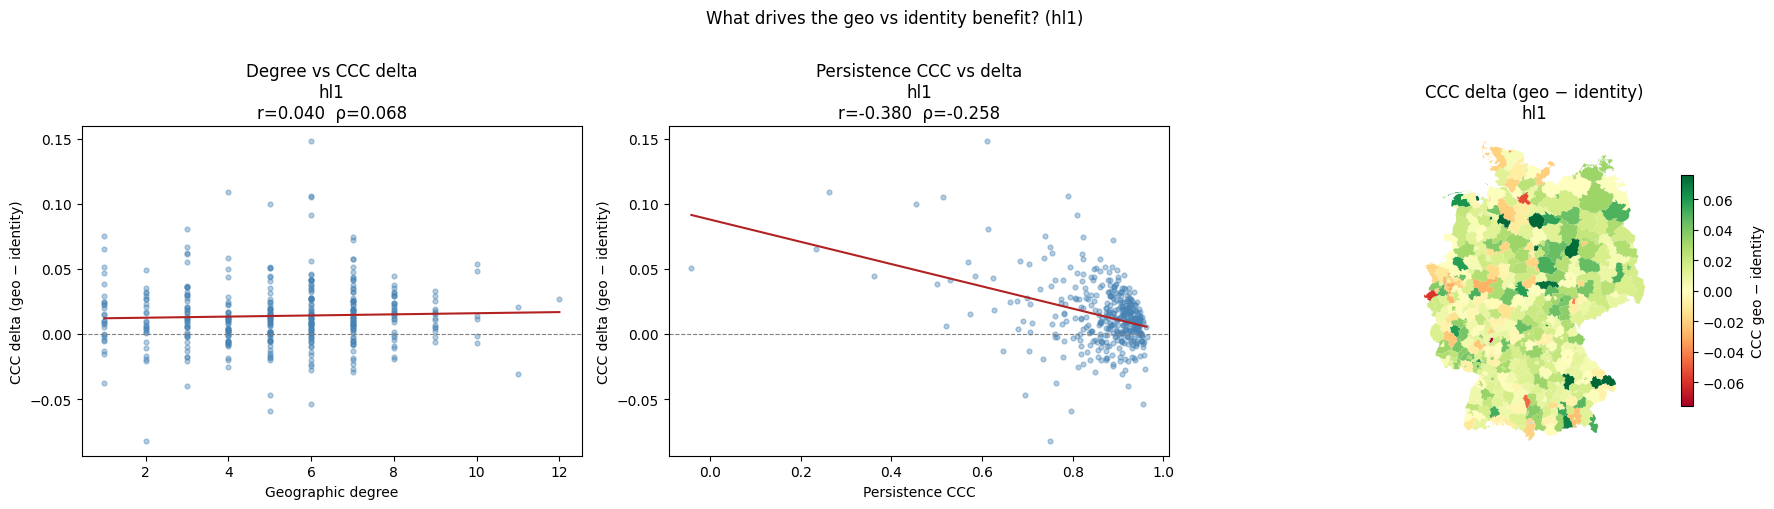


── Sociodemographic correlations with CCC delta ─────────────
  Population size     Pearson r=-0.1897 (p=0.0001)  Spearman ρ=-0.2403 (p=0.0000)
  Population density  Pearson r=-0.1854 (p=0.0002)  Spearman ρ=-0.2070 (p=0.0000)


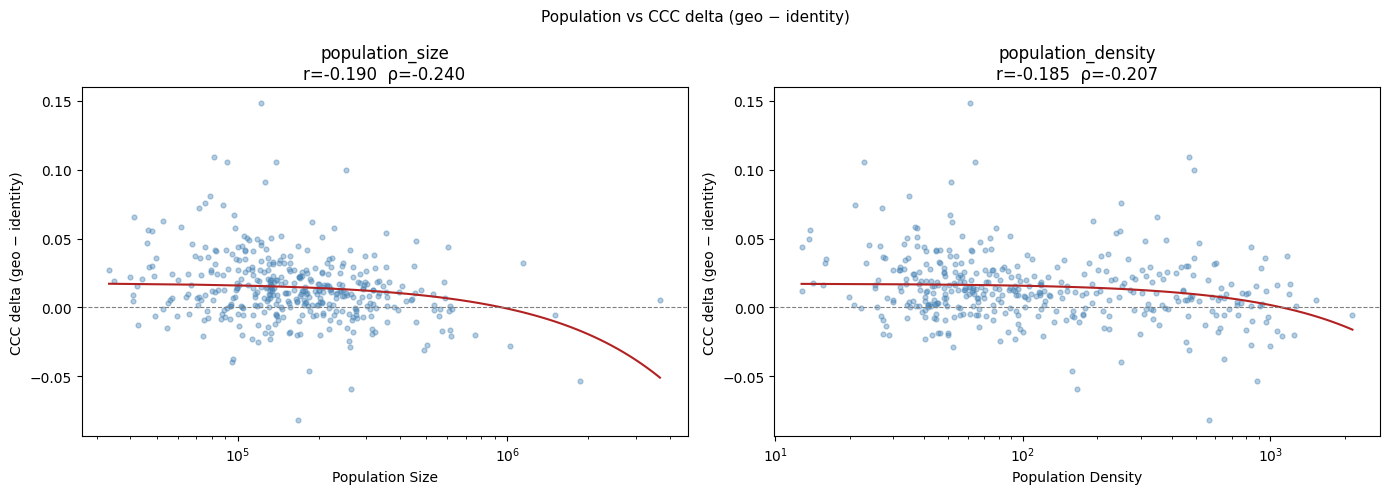

CCC delta (geo - identity) at hl10
  mean:   0.0021
  median: 0.0123
  min:    -0.3972  (node 90)
  max:    0.4596  (node 324)

Degree distribution:
  mean: 5.2  median: 5  min: 1  max: 12

── Correlations with CCC delta ──────────────────────────────
  Geographic degree         Pearson r=-0.0962 (p=0.0549)  Spearman ρ=-0.1381 (p=0.0057)
  Persistence CCC           Pearson r=-0.0271 (p=0.5899)  Spearman ρ=-0.1453 (p=0.0036)
  Incidence variance (geo)  Pearson r=+0.2875 (p=0.0000)  Spearman ρ=+0.4738 (p=0.0000)


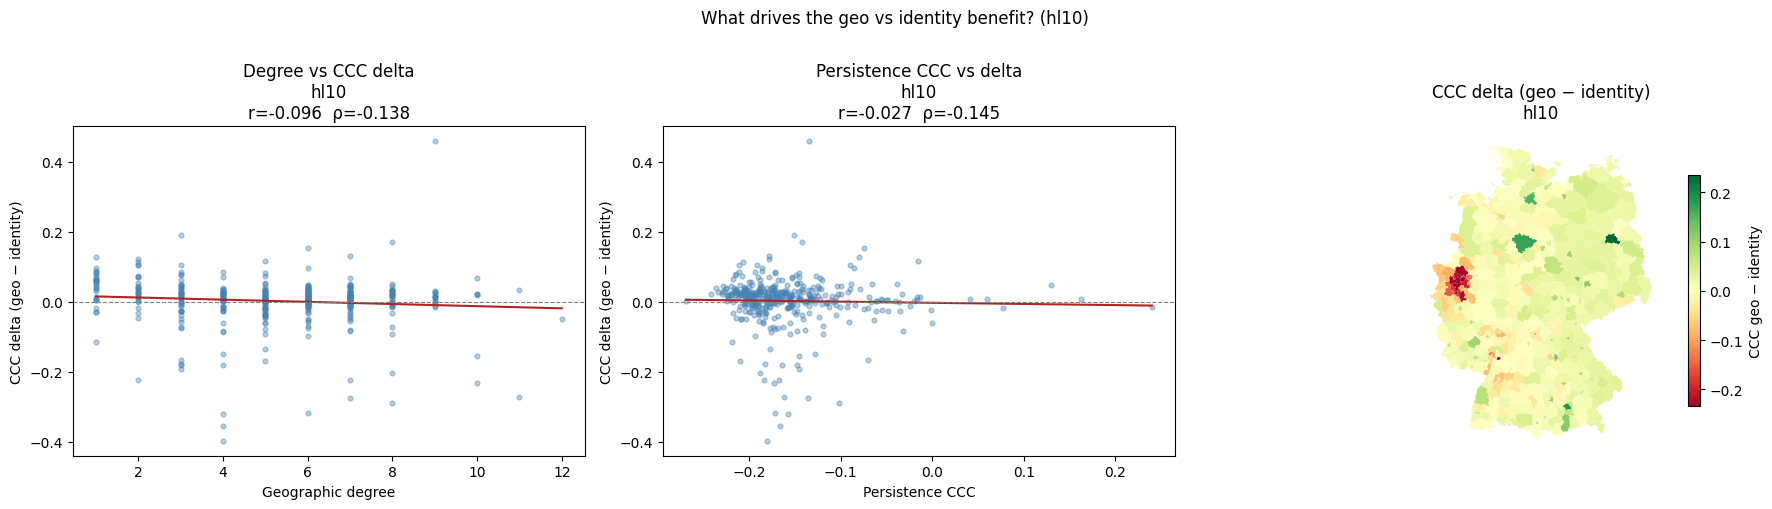


── Sociodemographic correlations with CCC delta ─────────────
  Population size     Pearson r=+0.2149 (p=0.0000)  Spearman ρ=-0.0901 (p=0.0722)
  Population density  Pearson r=-0.1377 (p=0.0059)  Spearman ρ=-0.1296 (p=0.0096)


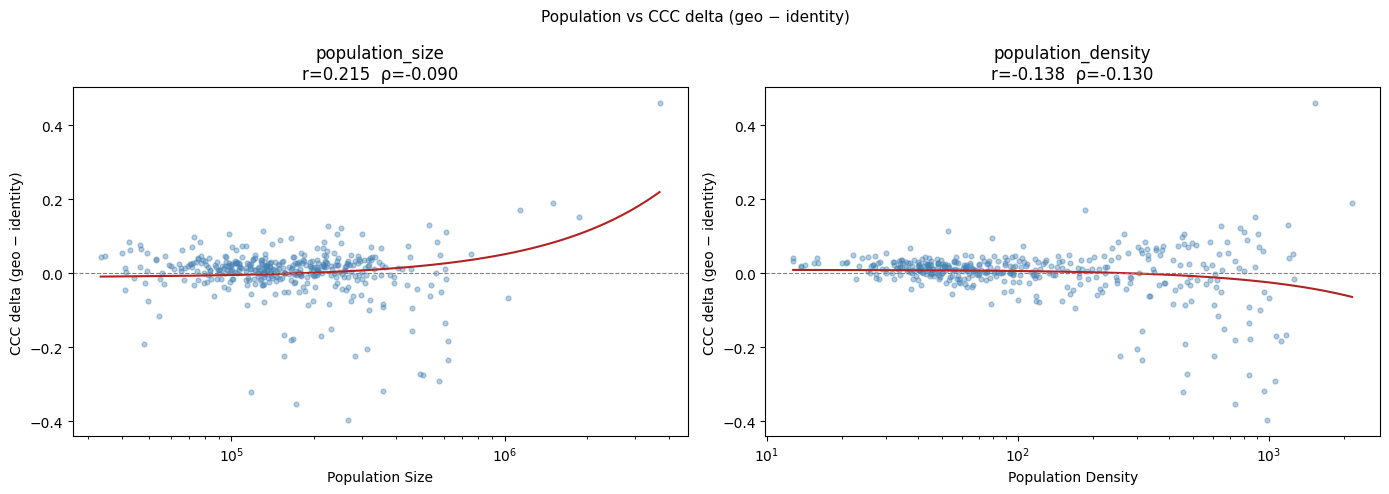

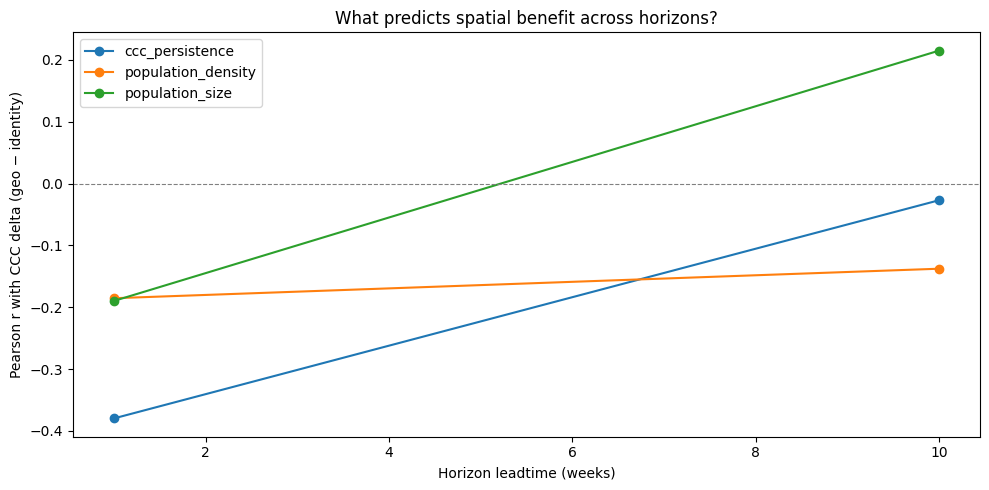

In [14]:
# Run the population correlation across ALL horizons and plot it
correlations = []

for hl_idx, hl in enumerate(horizon_leadtime_options):
    node_df_hl, _ = analyse_peripherality(
        evaluators=evaluators,
        ALLMODELS=ALLMODELS,
        horizon_idx=hl_idx,
        horizon_label=f'hl{hl}',
        geo_graph_dlm=graphloader_geographic,
        dataorchestrator=dataorchs[hl_idx],
    )
    node_df_hl, _ = add_sociodemographic_correlations(
        node_df=node_df_hl,
        dataorchestrator=dataorchs[hl_idx],
        evaluators=evaluators,
        horizon_idx=hl_idx,
    )
    
    for var in ['population_size', 'population_density', 'ccc_persistence']:
        if var not in node_df_hl.columns:
            continue
        clean = node_df_hl[['ccc_delta', var]].dropna()
        r, p     = stats.pearsonr( clean[var].astype(float), clean['ccc_delta'].astype(float))
        rho, p_s = stats.spearmanr(clean[var].astype(float), clean['ccc_delta'].astype(float))
        correlations.append({'horizon': hl, 'variable': var, 'pearson_r': r, 'spearman_rho': rho, 'p_pearson': p})

corr_df = pd.DataFrame(correlations)

# plot
fig, ax = plt.subplots(figsize=(10, 5))
for var, grp in corr_df.groupby('variable'):
    ax.plot(grp['horizon'], grp['pearson_r'], marker='o', label=var)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Horizon leadtime (weeks)')
ax.set_ylabel('Pearson r with CCC delta (geo − identity)')
ax.set_title('What predicts spatial benefit across horizons?')
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
def summary_table(evaluators, ALLMODELS, horizon_leadtime_options, model_indices):
    """
    Print and return mean CCC delta over persistence for selected models across all horizons.
    
    Parameters
    ----------
    evaluators              : list of Evaluator, one per horizon
    ALLMODELS               : list of lists, ALLMODELS[hl_idx][model_idx]
    horizon_leadtime_options: list of ints, e.g. [1,2,...,10]
    model_indices           : list of ints, e.g. [3,4,5,6,7]
    """
    rows = []

    for hl_idx, hl in enumerate(horizon_leadtime_options):
        metrics = (
            evaluators[hl_idx]
            .data_compilation
            .get_data(0, 'test')['metrics']
            .copy()
        )
        metrics['model'] = metrics['model'].astype(str)
        metrics['node']  = metrics['node'].astype(str)
        
        persistence_name = ALLMODELS[hl_idx][0].name
        pers_ccc = (
            metrics[metrics['model'] == persistence_name][['node', 'ccc']]
            .rename(columns={'ccc': 'ccc_pers'})
        )

        for idx in model_indices:
            name  = ALLMODELS[hl_idx][idx].name
            label = name.replace(f'_hl{hl}', '')

            model_ccc = (
                metrics[metrics['model'] == name][['node', 'ccc']]
            )
            merged = model_ccc.merge(pers_ccc, on='node')
            delta  = (merged['ccc'] - merged['ccc_pers']).mean()
            abs_ccc = merged['ccc'].mean()

            rows.append({
                'horizon': hl,
                'model':   label,
                'mean_delta': round(delta, 4),
                'mean_ccc':   round(abs_ccc, 4),
            })

    df = pd.DataFrame(rows)

    print("\n── CCC delta over persistence ───────────────────────────────")
    delta_table = df.pivot(index='model', columns='horizon', values='mean_delta')
    print(delta_table.to_string())

    print("\n── Absolute mean CCC ─────────────────────────────────────────")
    ccc_table = df.pivot(index='model', columns='horizon', values='mean_ccc')
    print(ccc_table.to_string())

    return delta_table, ccc_table

In [27]:
delta_table, ccc_table = summary_table(
    evaluators              = evaluators,
    ALLMODELS               = ALLMODELS,
    horizon_leadtime_options = horizon_leadtime_options,
    model_indices           = [3, 4, 5, 6, 7],  # lstm, id, geo, rnd, comm
)


── CCC delta over persistence ───────────────────────────────
horizon       1       2       3       4       5       6       7       8       9       10
model                                                                                   
gcn_comm  0.0316  0.1013  0.2188  0.3391  0.4760  0.6054  0.7142  0.7583  0.7829  0.8067
gcn_geo   0.0337  0.1028  0.2244  0.3573  0.4918  0.6211  0.7273  0.8046  0.8008  0.8366
gcn_id    0.0173  0.0855  0.1922  0.3153  0.4397  0.5629  0.6617  0.7448  0.7789  0.8310
gcn_rnd   0.0248  0.0793  0.2084  0.3403  0.4698  0.6005  0.7130  0.7886  0.7901  0.8436
lstm      0.0324  0.1056  0.2207  0.3484  0.4694  0.5719  0.6329  0.7905  0.7626  0.8279

── Absolute mean CCC ─────────────────────────────────────────
horizon       1       2       3       4       5       6       7       8       9       10
model                                                                                   
gcn_comm  0.8970  0.8582  0.8425  0.8309  0.8296  0.8197  0.8051  0.7435

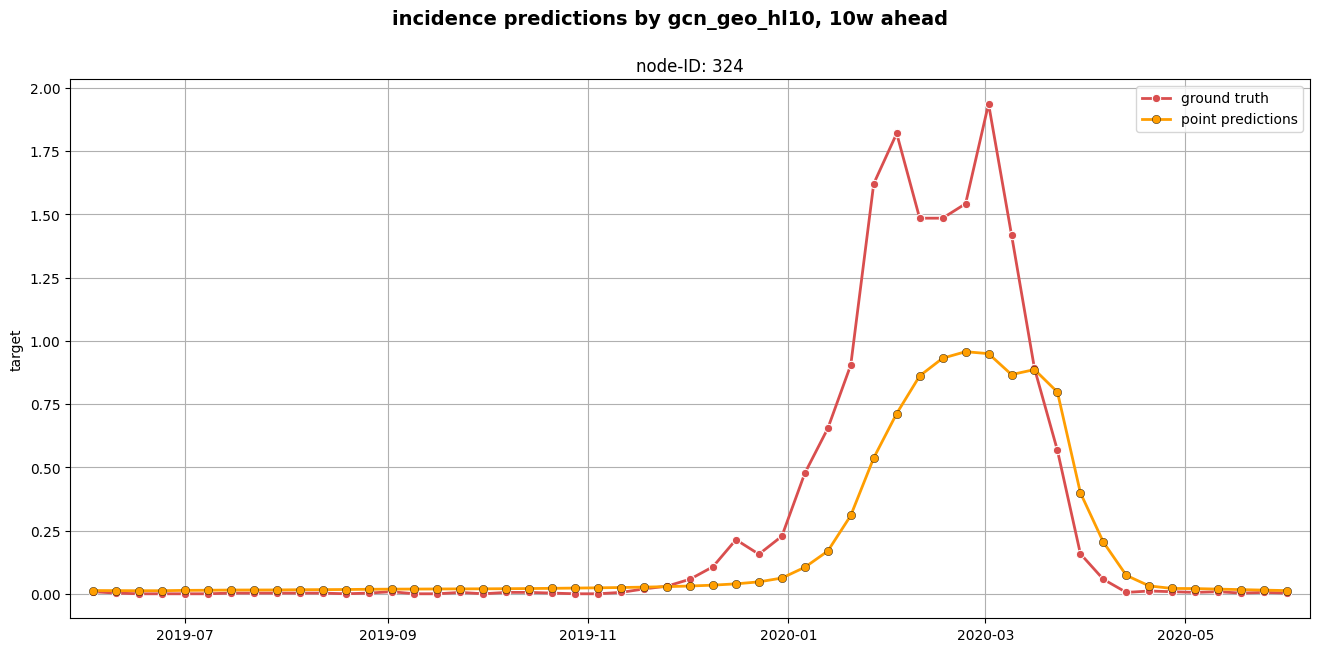

In [49]:
ALLMODELS[9][5].show_forecasts(324).show()